imports 

In [10]:
from astropy.io import fits
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import  numpy as np
from scipy import stats

all the calls we need for the analisis 

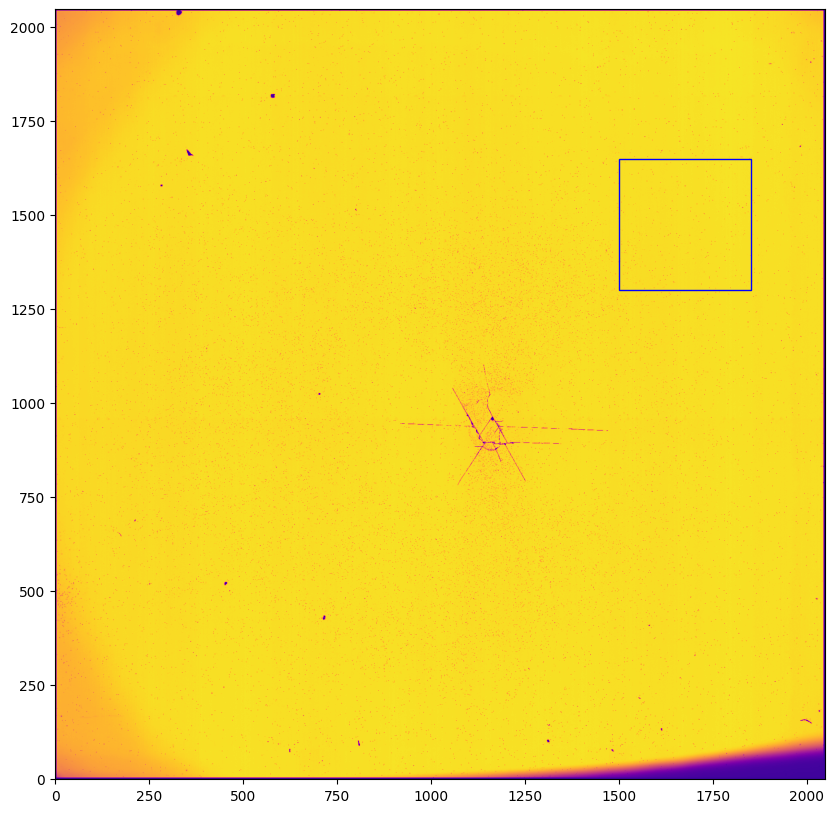

In [4]:


imagen = fits.open('difference_slow.fits')[0].data

#plot area inside the window


fig, ax = plt.subplots(figsize= (10,10)) #open the window to plot
ax.imshow(imagen[29,:,:], origin= 'lower', cmap= 'plasma') #plot the image all pixels frame 29, cmap = plasma(yellow purple map)

#create the space to analize
rect= patches.Rectangle(

(1500, 1300) ,#coordinates of start pixel
width= 350,
height= 350,
edgecolor= 'blue' ,
facecolor ='none' ,#we want to see the actual area
lw= 1,
)

ax.add_patch(rect) # add the patch to image



light_avg_names = [
'avg_light_fast.fits',
'avg_light_mid.fits',
'avg_light_slow.fits',
]
dark_avg_names =[
'avg_dark_fast.fits',
'avg_dark_mid.fits',
'avg_dark_slow.fits',
]
difference_names = [
'difference_fast.fits',
'difference_mid.fits',
'difference_slow.fits',
]

calculation means and medians

In [7]:


all_means_light=[] #empty list to fill
all_medians_light = []


for name in light_avg_names[:]: 
    file_means_light =[]  
    file_medians_light =[]
    f = fits.open(name)
    data = f[0].data.astype(np.float32)

    for i in range(30):
        region = data [i, 1300:1650, 1500:1850]  #get data from that region
        file_means_light.append(region.mean())  #put in file_means_light whats in region and take the mean
        file_medians_light.append(np.median(region)) # same but with median

    all_means_light.append(file_means_light)   #put in all_means_light whats in file_means_light    
    all_medians_light.append(file_medians_light)

all_means_dark =[]
all_medians_dark = []

for name in dark_avg_names[:]:
    file_means_dark = []
    file_medians_dark= []
    f=     fits.open(name)
    data = f[0].data.astype(np.float32)

    for i in range(30):
        region = data [i, 1300:1650, 1500:1850]
        file_means_dark.append(region.mean())
        file_medians_dark.append(np.median(region))
        
    all_means_dark.append(file_means_dark)
    all_medians_dark.append(file_medians_dark)
all_means_difference = []
all_medians_difference = []


for name in difference_names[:]:
    file_means_difference = []
    file_medians_difference =[]
    f=     fits.open(name)
    data = f[0].data.astype(np.float32)

    for i in range(30):
        region = data [i, 1300:1650, 1500:1850]
        file_means_difference.append(region.mean())
        file_medians_difference.append(np.median(region))

    all_means_difference.append(file_means_difference)
    all_medians_difference.append(file_medians_difference)



plotting data for fast medians and fast meands to sewe which to use 

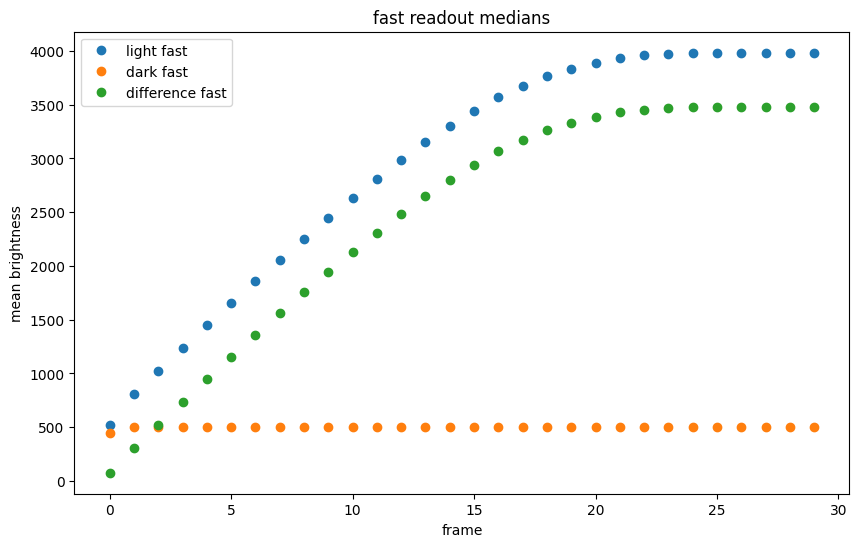

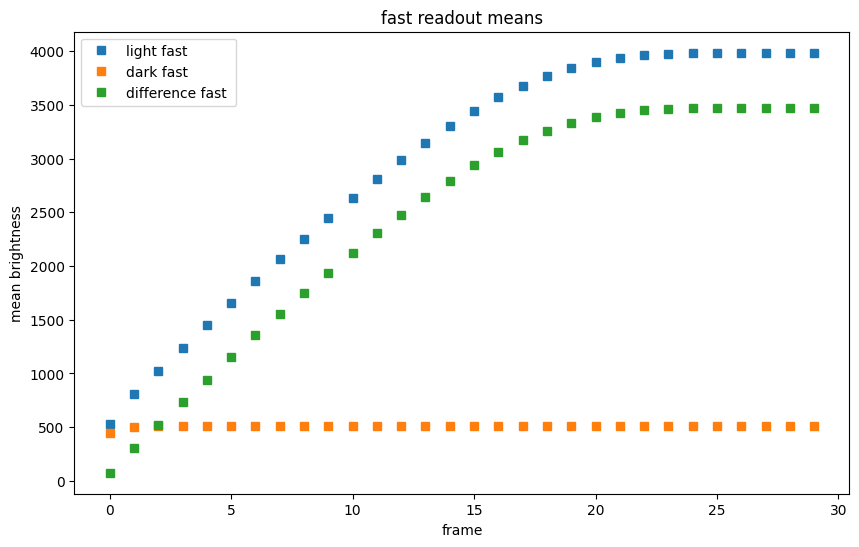

In [8]:


frames= range(30) #x values
plt.figure(figsize=(10,6)) #canvas 
plt.plot(frames, all_medians_light[0], 'o', label ='light fast') # x axis, y axis, label as :
plt.plot(frames, all_medians_dark[0], 'o', label= 'dark fast')
plt.plot (frames, all_medians_difference[0], 'o', label = 'difference fast')
plt.xlabel('frame') #xlabel
plt.ylabel('mean brightness') #ylabel
plt.title('fast readout medians') #title
plt.legend() 
plt.show()

plt.figure(figsize=(10,6)) #canvas 
plt.plot(frames, all_means_light[0], 's', label ='light fast') # x axis, y axis, label as :
plt.plot(frames, all_means_dark[0], 's', label= 'dark fast')
plt.plot (frames, all_means_difference[0], 's', label = 'difference fast ')
plt.xlabel('frame') #xlabel
plt.ylabel('mean brightness') #ylabel
plt.title('fast readout means') #title
plt.legend() 
plt.show()

cheking linearity with r pearson value

In [12]:
#for fast difference 
x= list(range(12)) #frame 1- n
y= all_medians_difference[0][:12]
r, p= stats.pearsonr(x,y)
print("pearson r fast =", r)
#plot the line

# defining  linear range
x_linear = list(range(12))                  # frames 0-11
y_linear = all_medians_difference[0][:12]     # first 12 brightness values

slope, intercept, r, p, se = stats.linregress(x_linear, y_linear)

print("Slope:", slope)
print("Intercept:", intercept)
print("R squared:", r**2)

#for mid difference
r_difference_mid, p = stats.pearsonr(list(range(12)), all_medians_difference[1][:12])
print("Pearson r mid:", r_difference_mid)

# for slow difference
r_difference_slow, p = stats.pearsonr(list(range(12)), all_medians_difference[2][:12])
print("Pearson r slow:", r_difference_slow)

#same for light 
r_light_fast= list(range(12)) #frame 1- n
y= all_medians_light[0][:12]
r_ligh_fast, p= stats.pearsonr(x,y)
print("pearson r fast =", r_ligh_fast)

r_ligh_mid,p =  stats.pearsonr(list(range(12)), all_medians_light[1][:12])
print("r light mid=", r_ligh_mid)
r_light_slow,p = stats.pearsonr(list(range(12)), all_medians_light[2][:12])
print("r light slow=",r_light_slow)

slope, intercept, r, p, se = stats.linregress(x_linear, y_linear)

print("Slope:", slope)
print("Intercept:", intercept)
print("R squared:", r**2)


pearson r fast = 0.9995179512087957
Slope: 203.22832142223012
Intercept: 115.18600463867188
R squared: 0.9990361347886287
Pearson r mid: 0.9995293235462968
Pearson r slow: 0.9996205284896341
pearson r fast = 0.9989983543949732
r light mid= 0.9995105002150728
r light slow= 0.9995901186347831
Slope: 203.22832142223012
Intercept: 115.18600463867188
R squared: 0.9990361347886287


In [13]:
    
names = ["fast", "mid", "slow"]
frame_axis = list(range(12))
slopes_diff = []
intercepts_diff = []
slopes_light = []
intercepts_light= []
print("LIGHT IMAGE")
for i in range(3):
    y=all_medians_light[i][:12]
    slope, intercept, r, p, se = stats.linregress(frame_axis, y)
    print(f"{names[i]}: slope={slope:.3f} intercept={intercept:.3f} r={r:.6f} r²={r**2:.3f}")
    slopes_light.append(slope)
    intercepts_light.append(intercept)

print("DIFFERENCE IMAGE")
for i in range(3):
    y=all_medians_difference[i][:12]
    slope, intercept, r, p, se = stats.linregress(frame_axis,y)
    print(f"{names[i]}: slope={slope:.3f} intercept={intercept:.3f} r={r:.6f}")
    slopes_diff.append(slope)
    intercepts_diff.append(intercept)
    
print("DARK IMAGE")
for i in range(3):
    y=all_medians_dark[i][:12]
    slope, intercept, r, p, se = stats.linregress(frame_axis,y)
    print(f"{names[i]}: slope={slope:.3f} intercept={intercept:.3f} r={r:.6f}")    
      

LIGHT IMAGE
fast: slope=204.892 intercept=604.667 r=0.998978 r²=0.998
mid: slope=3365.040 intercept=7636.580 r=0.999506 r²=0.999
slow: slope=3199.049 intercept=7126.496 r=0.999590 r²=0.999
DIFFERENCE IMAGE
fast: slope=202.555 intercept=114.772 r=0.999522
mid: slope=3359.266 intercept=2202.228 r=0.999501
slow: slope=3188.769 intercept=2092.585 r=0.999595
DARK IMAGE
fast: slope=2.337 intercept=489.896 r=0.504045
mid: slope=5.773 intercept=5434.352 r=0.987309
slow: slope=10.280 intercept=5033.911 r=0.992902


notice dark fast r value is really slow, not linear, is because slope is tiny and noise dominates

Deviation and at which frames exceeds the 5% threshold 

In [17]:
print("fast readout diff")

fitted_diff = [slopes_diff[0] * i + intercepts_diff[0] for i in range(30)]

for i in range(1, 30):
    real       = all_medians_difference[0][i]
    fitted_val = fitted_diff[i]
    deviation  = abs(real - fitted_val) / fitted_val * 100
    print(f"frame {i}: real={real:.1f} fitted={fitted_val:.1f} deviation={deviation:.2f}%")
    
    if deviation > 5:
        print(f"5% limit at frame {i}")
        break
 
#mid readout diff
print("mid readout diff")

fitted_diff = [slopes_diff[1] * i + intercepts_diff[1] for i in range(30)]

for i in range(2, 30):
    real       = all_medians_difference[1][i]
    fitted_val = fitted_diff[i]
    deviation  = abs(real - fitted_val) / fitted_val * 100
    print(f"frame {i}: real={real:.1f} fitted={fitted_val:.1f} deviation={deviation:.2f}%")
    
    if deviation > 5:
        print(f"5% limit at frame {i}")
        break    
    
#slow readout diff
print("slow readout diff")

fitted_diff = [slopes_diff[2] * i + intercepts_diff[2] for i in range(30)]

for i in range(1, 30):
    real       = all_medians_difference[2][i]
    fitted_val = fitted_diff[i]
    deviation  = abs(real - fitted_val) / fitted_val * 100
    print(f"frame {i}: real={real:.1f} fitted={fitted_val:.1f} deviation={deviation:.2f}%")
    
    if deviation > 5:
        print(f"5% limit at frame {i}")
        break   

#light fast read out
print("light fast readout")
fitted_light = [slopes_light[0] * i + intercepts_light[0] for i in range(30)]

for i in range(1, 30):
    real       = all_medians_light[0][i]
    fitted_val = fitted_light[i]
    deviation  = abs(real - fitted_val) / fitted_val * 100
    print(f"frame {i}: real={real:.1f} fitted={fitted_val:.1f} deviation={deviation:.2f}%")
    
    if deviation > 5:
        print(f"5% limit at frame {i}")
        break   
#light mid readout
print("light mid readout")
fitted_light = [slopes_light[1] * i + intercepts_light[1] for i in range(30)]

for i in range(1, 30):
    real       = all_medians_light[1][i]
    fitted_val = fitted_light[i]
    deviation  = abs(real - fitted_val) / fitted_val * 100
    print(f"frame {i}: real={real:.1f} fitted={fitted_val:.1f} deviation={deviation:.2f}%")
    
    if deviation > 5:
        print(f"5% limit at frame {i}")
        break       

#light slow readout
print("light slow readout")
fitted_light = [slopes_light[2] * i + intercepts_light[2] for i in range(30)]

for i in range(1, 30):
    real       = all_medians_light[2][i]
    fitted_val = fitted_light[i]
    deviation  = abs(real - fitted_val) / fitted_val * 100
    print(f"frame {i}: real={real:.1f} fitted={fitted_val:.1f} deviation={deviation:.2f}%")
    
    if deviation > 5:
        print(f"5% limit at frame {i}")
        break       
    

fast readout diff
frame 1: real=303.6 fitted=317.3 deviation=4.33%
frame 2: real=521.1 fitted=519.9 deviation=0.23%
frame 3: real=734.6 fitted=722.4 deviation=1.68%
frame 4: real=946.2 fitted=925.0 deviation=2.29%
frame 5: real=1154.9 fitted=1127.5 deviation=2.43%
frame 6: real=1359.3 fitted=1330.1 deviation=2.20%
frame 7: real=1558.6 fitted=1532.7 deviation=1.69%
frame 8: real=1753.4 fitted=1735.2 deviation=1.05%
frame 9: real=1944.2 fitted=1937.8 deviation=0.33%
frame 10: real=2131.6 fitted=2140.3 deviation=0.41%
frame 11: real=2310.9 fitted=2342.9 deviation=1.37%
frame 12: real=2483.2 fitted=2545.4 deviation=2.45%
frame 13: real=2647.0 fitted=2748.0 deviation=3.68%
frame 14: real=2801.2 fitted=2950.5 deviation=5.06%
5% limit at frame 14
mid readout diff
frame 2: real=8948.3 fitted=8920.8 deviation=0.31%
frame 3: real=12522.4 fitted=12280.0 deviation=1.97%
frame 4: real=16019.8 fitted=15639.3 deviation=2.43%
frame 5: real=19465.7 fitted=18998.6 deviation=2.46%
frame 6: real=22843.3 f

plotting data 

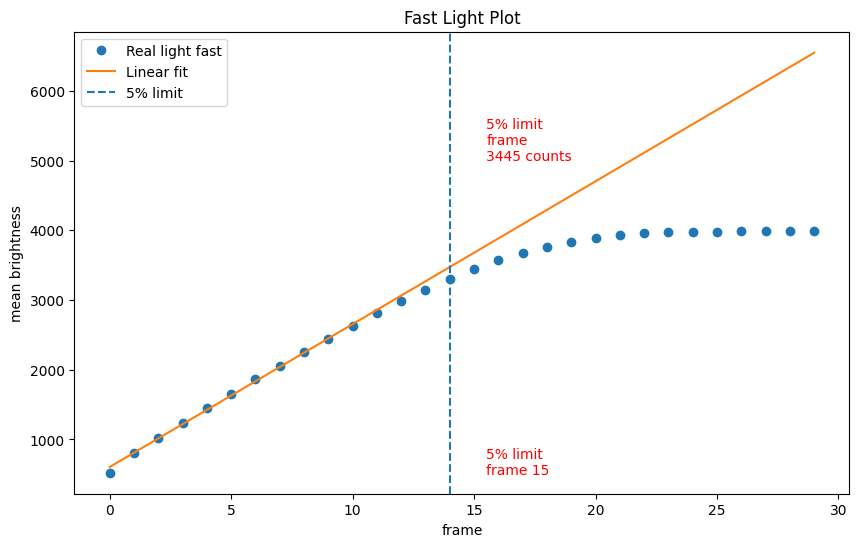

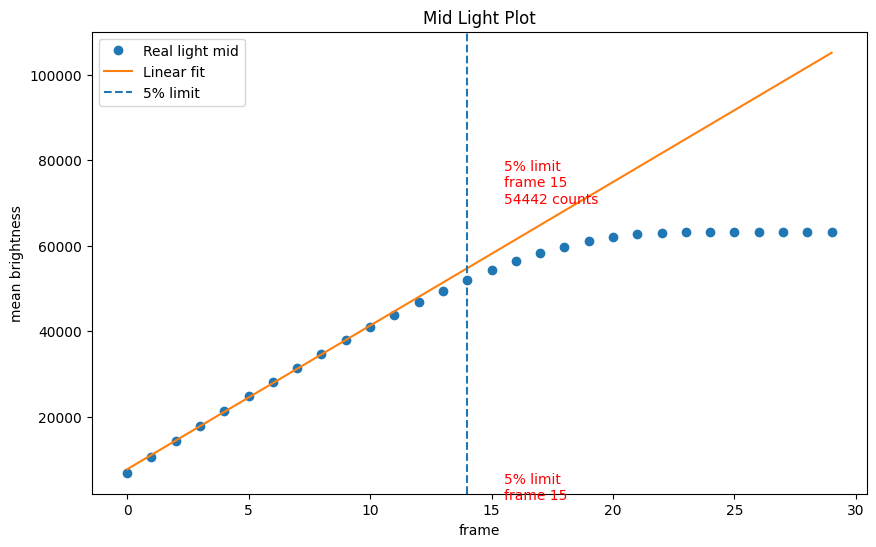

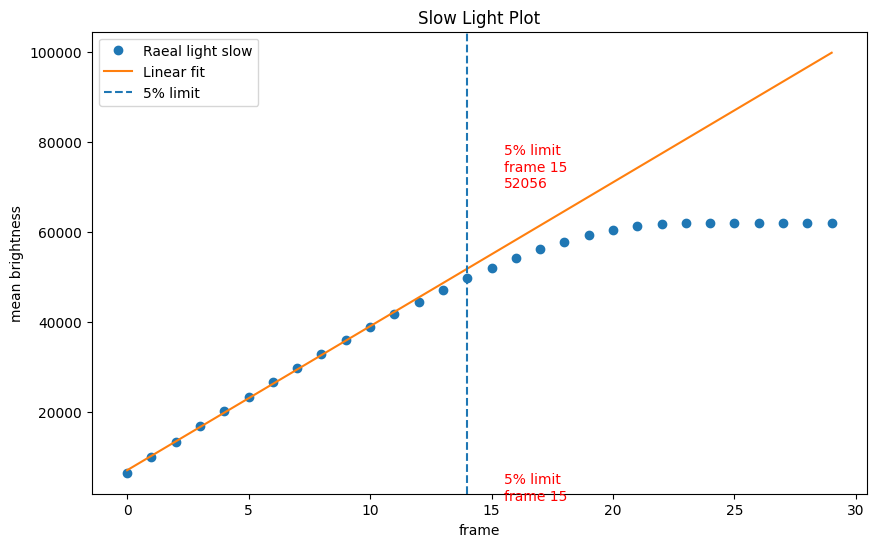

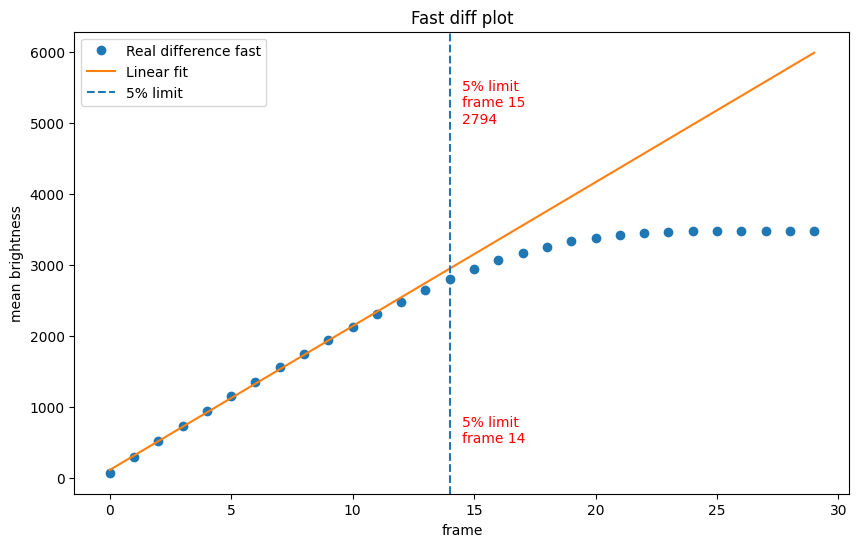

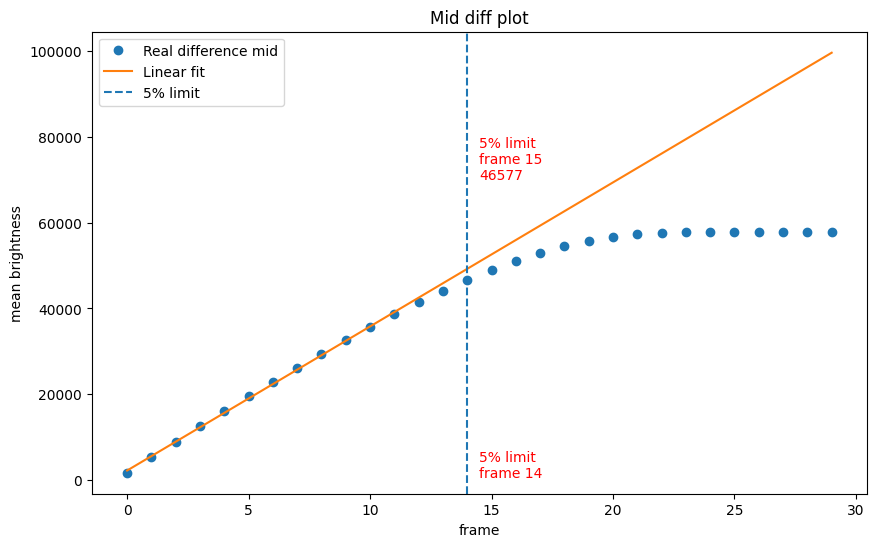

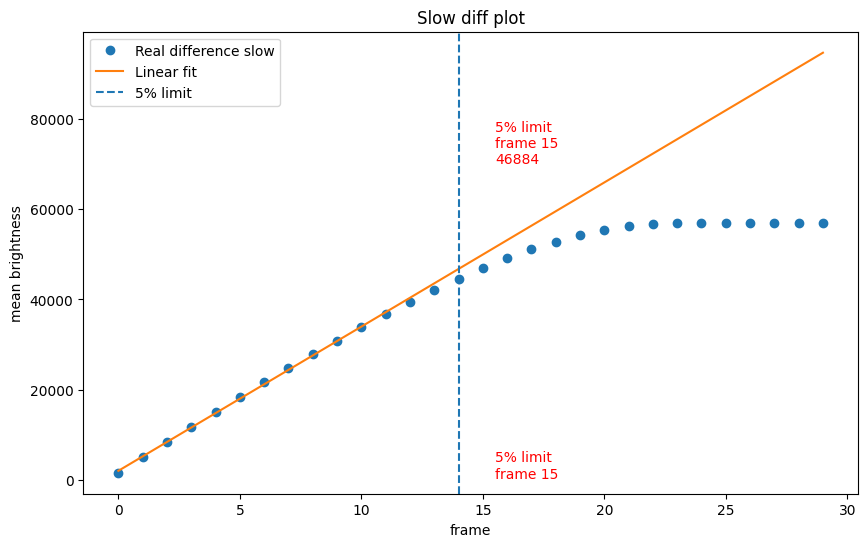

In [28]:
fitted_diff_all = []
for i in range(3):
    fitted = [slopes_diff[i] * j + intercepts_diff[i] for j in range(30)]
    fitted_diff_all.append(fitted)

fitted_light_all = []
for i in range(3):
    fitted = [slopes_light[i] * j + intercepts_light[i] for j in range(30)]
    fitted_light_all.append(fitted)   
#plotting data 
#fast readout plots
frames= range(30) #x values
plt.figure(figsize=(10,6)) #canvas 
plt.plot (frames, all_medians_light[0], 'o', label = 'Real light fast')
plt.plot(frames, fitted_light_all[0], label ="Linear fit")
plt.axvline(x=14, linestyle ='--', label='5% limit')
plt.text(15.5, 5000, f'5% limit\nframe\n3445 counts', color='red', fontsize =10)
plt.text(15.5, 500, '5% limit\nframe 15', color='red', fontsize=10)
plt.xlabel('frame') #xlabel
plt.ylabel('mean brightness') #ylabel
plt.title('Fast Light Plot') #title
plt.legend() 

#mid readout plots
frames= range(30) #x values
plt.figure(figsize=(10,6)) #canvas 
plt.plot (frames, all_medians_light[1], 'o', label = 'Real light mid')
plt.plot(frames, fitted_light_all[1], label ="Linear fit")
plt.axvline(x=14, linestyle ='--', label='5% limit')
plt.text(15.5,70000, f'5% limit\nframe 15\n54442 counts', color='red', fontsize =10)
plt.text(15.5, 500, '5% limit\nframe 15', color='red', fontsize=10)
plt.xlabel('frame') #xlabel
plt.ylabel('mean brightness') #ylabel
plt.title('Mid Light Plot') #title
plt.legend() 

#slow readout plots
frames= range(30) #x values
plt.figure(figsize=(10,6)) #canvas 
plt.plot (frames, all_medians_light[2], 'o', label = 'Raeal light slow')
plt.plot(frames, fitted_light_all[2], label ="Linear fit")
plt.text(15.5, 70000, f'5% limit\nframe 15\n52056', color='red', fontsize =10)
plt.axvline(x=14, linestyle ='--', label='5% limit')
plt.text(15.5, 500, '5% limit\nframe 15', color='red', fontsize=10)
plt.xlabel('frame') #xlabel
plt.ylabel('mean brightness') #ylabel
plt.title('Slow Light Plot') #title
plt.legend() 


frames= range(30) #x values
plt.figure(figsize=(10,6)) #canvas 
plt.plot (frames, all_medians_difference[0], 'o', label = 'Real difference fast')
plt.plot(frames, fitted_diff_all[0], label ="Linear fit")
plt.axvline(x=14, linestyle ='--', label='5% limit')
plt.text(14.5, 5000, f'5% limit\nframe 15\n2794', color='red', fontsize =10)
plt.text(14.5, 500, '5% limit\nframe 14', color='red', fontsize=10)
plt.xlabel('frame') #xlabel
plt.ylabel('mean brightness') #ylabel
plt.title('Fast diff plot') #title
plt.legend() 
plt.show()

#mid readout plots
frames= range(30) #x values
plt.figure(figsize=(10,6)) #canvas 
plt.plot (frames, all_medians_difference[1], 'o', label = 'Real difference mid')
plt.plot(frames, fitted_diff_all[1], label ="Linear fit")
plt.text(14.5, 70000, f'5% limit\nframe 15\n46577', color='red', fontsize =10)
plt.axvline(x=14, linestyle ='--', label='5% limit')
plt.text(14.5, 500, '5% limit\nframe 14', color='red', fontsize=10)
plt.xlabel('frame') #xlabel
plt.ylabel('mean brightness') #ylabel
plt.title('Mid diff plot') #title
plt.legend() 
plt.show()

#slow readout plots
frames= range(30) #x values
plt.figure(figsize=(10,6)) #canvas 
plt.plot (frames, all_medians_difference[2], 'o', label = 'Real difference slow')
plt.plot(frames, fitted_diff_all[2], label ="Linear fit")
plt.text(15.5, 70000, f'5% limit\nframe 15\n46884', color='red', fontsize =10)
plt.axvline(x=14, linestyle ='--', label='5% limit')
plt.text(15.5, 500, '5% limit\nframe 15', color='red', fontsize=10)
plt.xlabel('frame') #xlabel
plt.ylabel('mean brightness') #ylabel
plt.title('Slow diff plot') #title
plt.legend() 
plt.show()


Brightness value 

In [22]:
print ("DARK SUBSTRACTED: ")
print("Diff fast count at limit:", all_means_difference[0][14])
print("Diff mid count at limit:",  all_means_difference[1][14])
print("Diff slow count at limit:", all_means_difference[2][15])
print("RAW:")
print("Light fast count at limit:", all_means_light[0][15])
print("Light mid count at limit:",  all_means_light[1][15])
print("Light slow count at limit:", all_means_light[2][15])

DARK SUBSTRACTED: 
Diff fast count at limit: 2794.073
Diff mid count at limit: 46576.79
Diff slow count at limit: 46883.918
RAW:
Light fast count at limit: 3444.8103
Light mid count at limit: 54441.844
Light slow count at limit: 52055.5
